# Lab 6 – CNN for Image Classification

In [5]:
# Import required libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [6]:
# Set project parameters
DATASET_PATH = "./lab6/data"
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 5

tf.random.set_seed(SEED)
np.random.seed(SEED)

In [7]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\Shruti\Documents\Aadit\DL_Lab
['.git', 'desktop.ini', 'lab1', 'lab2', 'lab3', 'lab6']


In [8]:
# Load training and validation datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Found 1500 files belonging to 5 classes.
Using 1200 files for training.
Found 1500 files belonging to 5 classes.
Using 300 files for validation.
Classes: ['cbb', 'cbsd', 'cgm', 'cmd', 'healthy']
Number of classes: 5


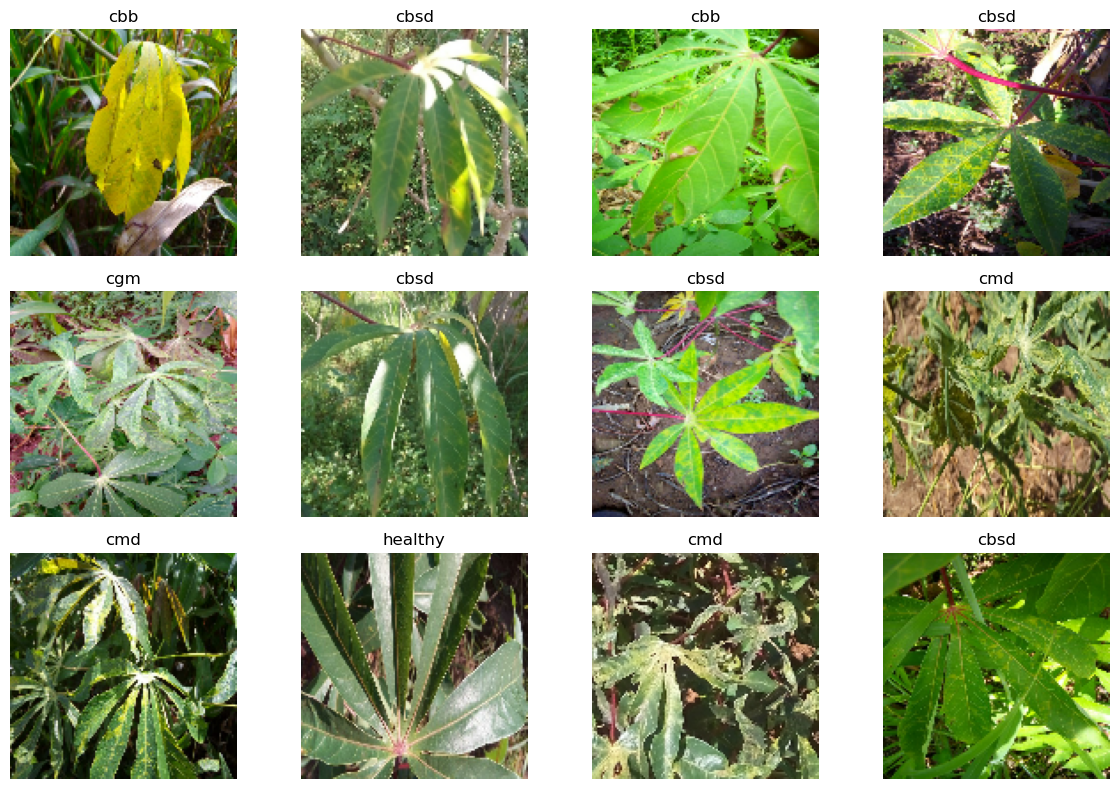

In [9]:
# Display sample images
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(min(12, len(images))):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

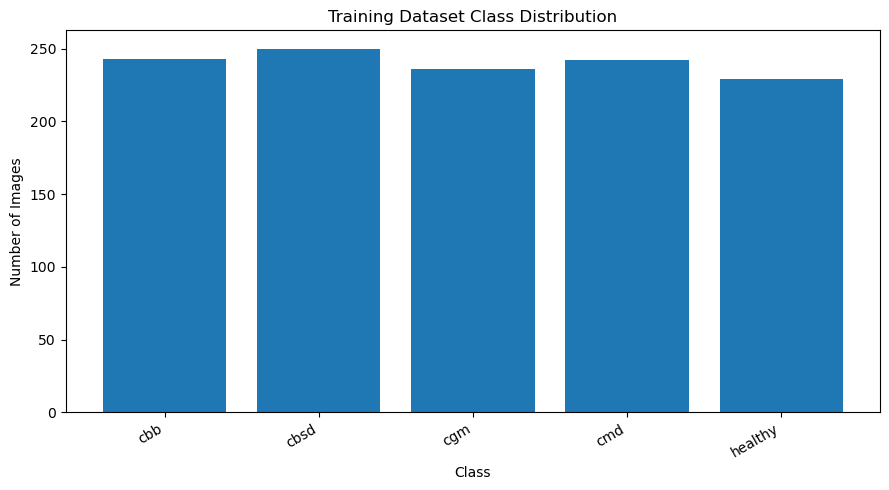

{'cbb': np.int64(243), 'cbsd': np.int64(250), 'cgm': np.int64(236), 'cmd': np.int64(242), 'healthy': np.int64(229)}


In [10]:
# Visualize class distribution
class_counts = np.zeros(num_classes, dtype=int)

for _, labels in train_ds.unbatch():
    class_counts[int(labels.numpy())] += 1

plt.figure(figsize=(9, 5))
plt.bar(class_names, class_counts)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Training Dataset Class Distribution")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print(dict(zip(class_names, class_counts)))

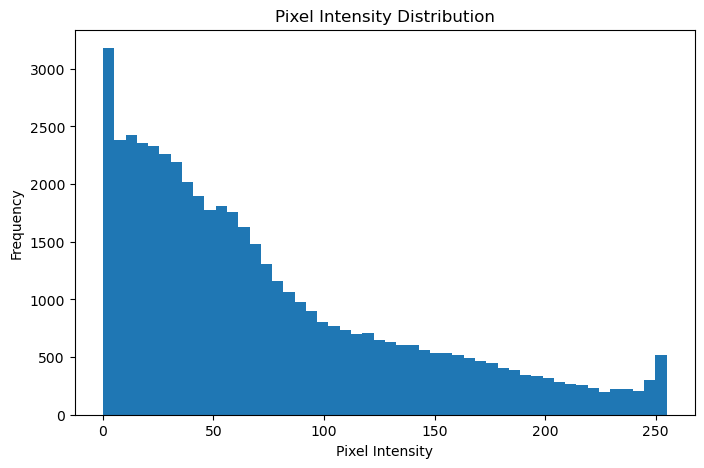

In [11]:
# Visualize pixel intensity distribution for a sample image
sample_image = next(iter(train_ds))[0][0].numpy()

plt.figure(figsize=(8, 5))
plt.hist(sample_image.flatten(), bins=50)
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.title("Pixel Intensity Distribution")
plt.show()

In [12]:
# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10)
])

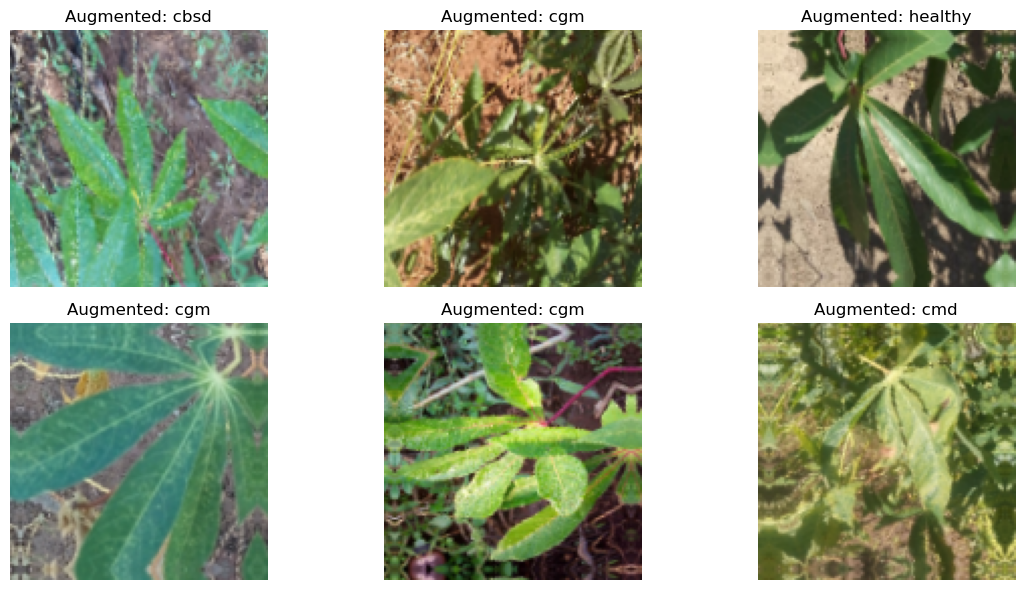

In [13]:
# Visualize augmented images
images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 6))

for i in range(6):
    augmented_image = data_augmentation(tf.expand_dims(images[i], 0), training=True)[0]
    ax = plt.subplot(2, 3, i + 1)
    plt.imshow(tf.cast(augmented_image, tf.uint8))
    plt.title("Augmented: " + class_names[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
# Improve dataset loading performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

In [15]:
# Build CNN model
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    data_augmentation,
    layers.Rescaling(1.0 / 255),

    # Convolutional Block 1
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Convolutional Block 2
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Convolutional Block 3
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Convolutional Block 4
    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.30),

    # Classification layers
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.40),
    layers.Dense(num_classes, activation="softmax")
], name="CNN_Image_Classifier")

model.summary()

Model: "CNN_Image_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,877 (1.62 MB)

 Trainable params: 422,917 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [16]:
# Compile the CNN
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [17]:
# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/5


c:\Users\Shruti\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


38/38 ━━━━━━━━━━━━━━━━━━━━ 145s 3s/step - accuracy: 0.2692 - loss: 1.7685 - val_accuracy: 0.1667 - val_loss: 1.7111
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 138s 3s/step - accuracy: 0.3458 - loss: 1.4890 - val_accuracy: 0.1900 - val_loss: 2.1014
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 141s 3s/step - accuracy: 0.3725 - loss: 1.4191 - val_accuracy: 0.1800 - val_loss: 2.4526
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 123s 3s/step - accuracy: 0.4033 - loss: 1.3773 - val_accuracy: 0.1667 - val_loss: 2.5233
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 106s 3s/step - accuracy: 0.4117 - loss: 1.3643 - val_accuracy: 0.1667 - val_loss: 2.9095


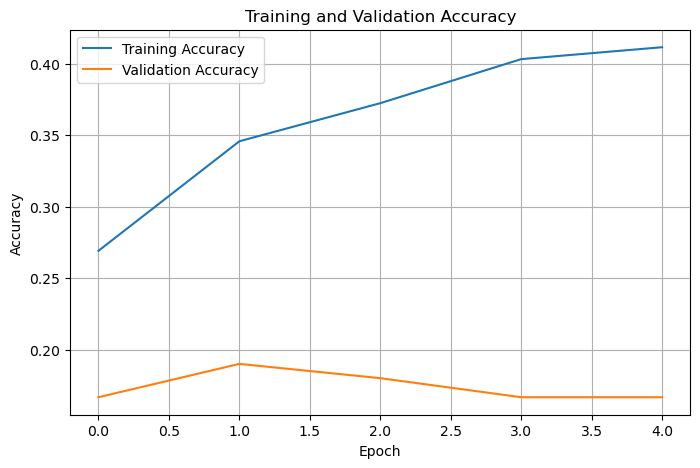

In [18]:
# Plot training and validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

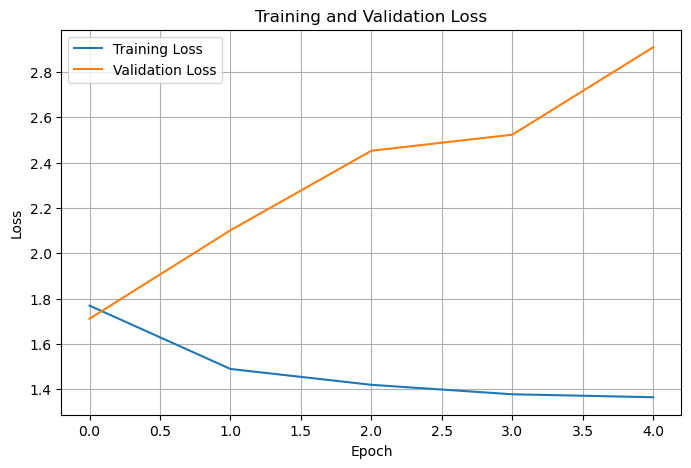

In [19]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
# Evaluate the model
val_loss, val_accuracy = model.evaluate(val_ds, verbose=1)

print("Validation Loss:", round(val_loss, 4))
print("Validation Accuracy:", round(val_accuracy * 100, 2), "%")

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 331ms/step - accuracy: 0.1667 - loss: 2.9095
Validation Loss: 2.9095
Validation Accuracy: 16.67 %


In [21]:
# Generate predictions for the validation dataset
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

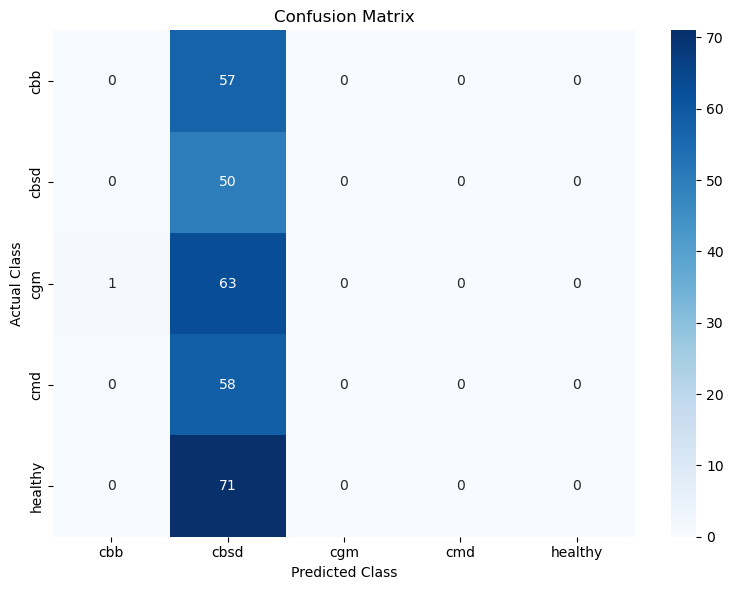

In [22]:
# Display confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [23]:
# Classification report
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
))

              precision    recall  f1-score   support

         cbb       0.00      0.00      0.00        57
        cbsd       0.17      1.00      0.29        50
         cgm       0.00      0.00      0.00        64
         cmd       0.00      0.00      0.00        58
     healthy       0.00      0.00      0.00        71

    accuracy                           0.17       300
   macro avg       0.03      0.20      0.06       300
weighted avg       0.03      0.17      0.05       300



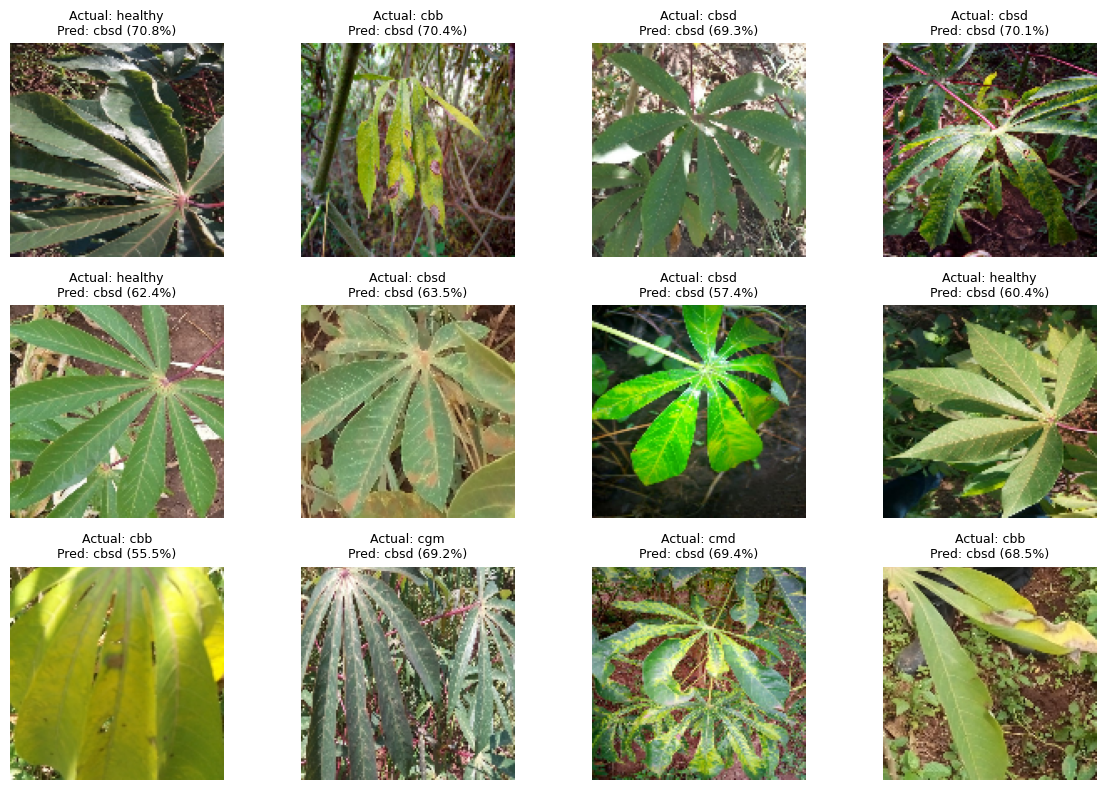

In [24]:
# Display sample predictions
images, labels = next(iter(val_ds))
predictions = model.predict(images, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(12, 8))

for i in range(min(12, len(images))):
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))

    actual = class_names[labels[i]]
    predicted = class_names[predicted_labels[i]]
    confidence = predictions[i][predicted_labels[i]] * 100

    plt.title(
        f"Actual: {actual}\nPred: {predicted} ({confidence:.1f}%)",
        fontsize=9
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

Incorrect predictions in displayed batch: 25


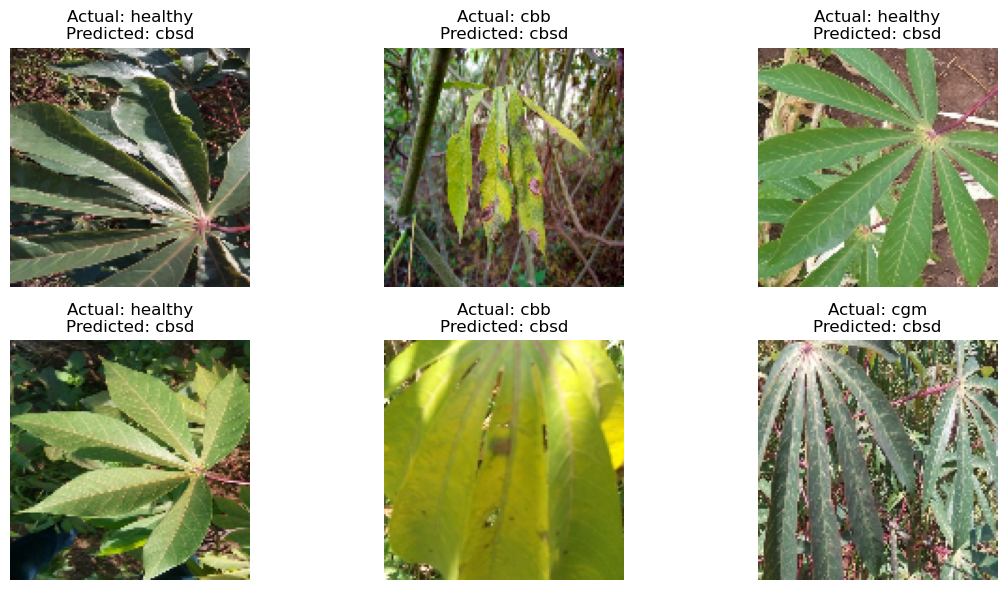

In [25]:
# Display incorrectly classified images
incorrect_indices = np.where(predicted_labels != labels.numpy())[0]

print("Incorrect predictions in displayed batch:", len(incorrect_indices))

if len(incorrect_indices) > 0:
    plt.figure(figsize=(12, 6))

    for plot_index, image_index in enumerate(incorrect_indices[:6]):
        ax = plt.subplot(2, 3, plot_index + 1)
        plt.imshow(images[image_index].numpy().astype("uint8"))

        actual = class_names[labels[image_index]]
        predicted = class_names[predicted_labels[image_index]]

        plt.title(f"Actual: {actual}\nPredicted: {predicted}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No incorrect predictions found in this batch.")

In [26]:
# Save the trained CNN model
model.save("cnn_image_classifier.keras")
print("Model saved as cnn_image_classifier.keras")

Model saved as cnn_image_classifier.keras


In [27]:
# Predict a new external image
# Place test_leaf.jpeg in the same folder as this notebook before running this cell.

from tensorflow.keras.utils import load_img, img_to_array

image_path = "test_leaf.jpeg"

try:
    img = load_img(image_path, target_size=IMG_SIZE)
    img_array = img_to_array(img)
    img_array = tf.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)
    predicted_index = np.argmax(prediction[0])
    predicted_class = class_names[predicted_index]
    confidence = prediction[0][predicted_index] * 100

    print("Predicted Class:", predicted_class)
    print("Confidence:", round(confidence, 2), "%")

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")
    plt.axis("off")
    plt.show()

except FileNotFoundError:
    print("test_leaf.jpeg not found. Add the image to the notebook folder and run this cell again.")

test_leaf.jpeg not found. Add the image to the notebook folder and run this cell again.
